In [ ]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, PercentFormatter
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "outputs").exists() and (PROJECT_ROOT.parent / "outputs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = PROJECT_ROOT / "figures"
PRESENTATION_FIGURES_DIR = FIGURES_DIR / "presentation"
PRESENTATION_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("PRESENTATION_FIGURES_DIR:", PRESENTATION_FIGURES_DIR)

# Глобальный стиль
plt.rcParams.update({
    "figure.figsize": (16, 9),
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "font.size": 22,
    "axes.titlesize": 30,
    "axes.labelsize": 24,
    "xtick.labelsize": 21,
    "ytick.labelsize": 21,
    "legend.fontsize": 20,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

COLORS = {
    "LSI": "#4C78A8",
    "LDA": "#F58518",
    "BERTopic": "#54A24B",
    "BigARTM": "#B279A2",
    "Qwen2.5": "#E45756",
    "gray": "#6B7280",
    "light_gray": "#E5E7EB",
}

FIGURE_MANIFEST = []

PROJECT_ROOT: c:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis
OUTPUT_DIR: c:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\outputs
PRESENTATION_FIGURES_DIR: c:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\presentation


In [ ]:
def read_csv_if_exists(path: Path, **kwargs) -> pd.DataFrame | None:
    # Безопасно читает CSV. Если файла нет или он битый, возвращает None.
    if not path.exists():
        print(f"Нет файла: {path.name}")
        return None
    try:
        return pd.read_csv(path, **kwargs)
    except Exception as e:
        print(f"Не удалось прочитать {path.name}: {e}")
        return None


def save_figure(filename: str, title: str, note: str = "") -> Path:
    path = PRESENTATION_FIGURES_DIR / filename
    plt.savefig(path, bbox_inches="tight", facecolor="white")
    FIGURE_MANIFEST.append({
        "file": str(path.relative_to(PROJECT_ROOT)),
        "title": title,
        "note": note,
    })
    print("Сохранено:", path)
    return path


def annotate_bars(ax, bars, fmt="{:.3f}", dy=0.012, fontsize=24):
    # Подписывает значения над вертикальными столбцами.
    heights = [bar.get_height() for bar in bars]
    max_h = max(heights) if heights else 1
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + max_h * dy,
            fmt.format(h),
            ha="center",
            va="bottom",
            fontsize=fontsize,
            fontweight="bold",
        )


def clean_model_name(name: str) -> str:
    mapping = {
        "lda": "LDA",
        "lsi": "LSI",
        "bertopic": "BERTopic",
        "bigartm": "BigARTM",
    }
    return mapping.get(str(name).strip().lower(), str(name).strip())


def normalize_metric_columns(df: pd.DataFrame) -> pd.DataFrame:
    # Приводит разные варианты названий колонок метрик к единому виду.
    df = df.copy()
    rename_map = {
        "coherence": "coherence_cv",
        "c_v": "coherence_cv",
        "cv": "coherence_cv",
        "u_mass": "coherence_umass",
        "umass": "coherence_umass",
        "topics": "num_topics",
        "n_topics": "num_topics",
    }
    df = df.rename(columns={c: rename_map.get(c, c) for c in df.columns})
    if "model" in df.columns:
        df["model"] = df["model"].apply(clean_model_name)
    return df


def plot_value_cards(ax, rows, title, subtitle=None):
    # Минималистичная панель с крупными числами.
    ax.axis("off")
    ax.set_title(title, pad=20)
    if subtitle:
        ax.text(0.5, 0.93, subtitle, ha="center", va="center", fontsize=22, color=COLORS["gray"], transform=ax.transAxes)
    y_positions = np.linspace(0.72, 0.18, len(rows))
    for y, (label, value, comment, color) in zip(y_positions, rows):
        ax.text(0.08, y, label, ha="left", va="center", fontsize=24, fontweight="bold", transform=ax.transAxes)
        ax.text(0.52, y, value, ha="center", va="center", fontsize=42, fontweight="bold", color=color, transform=ax.transAxes)
        ax.text(0.82, y, comment, ha="center", va="center", fontsize=21, color=COLORS["gray"], transform=ax.transAxes)

In [ ]:
# Резервные значения нужны только для того, чтобы графики можно было построить даже без папки outputs
fallback_metrics = pd.DataFrame([
    {"model": "LSI",      "num_topics": 5,   "coherence_cv": 0.579, "coherence_umass": np.nan, "perplexity": np.nan, "source": "fallback"},
    {"model": "LDA",      "num_topics": 25,  "coherence_cv": 0.551, "coherence_umass": np.nan, "perplexity": np.nan, "source": "fallback"},
    {"model": "BERTopic", "num_topics": 103, "coherence_cv": 0.668, "coherence_umass": np.nan, "perplexity": np.nan, "source": "fallback"},
    {"model": "BigARTM",  "num_topics": 30,  "coherence_cv": 0.667, "coherence_umass": np.nan, "perplexity": np.nan, "source": "fallback"},
])

metric_files = {
    "LDA": OUTPUT_DIR / "lda_final_metrics.csv",
    "LSI": OUTPUT_DIR / "lsi_final_metrics.csv",
    "BERTopic": OUTPUT_DIR / "bertopic_final_metrics.csv",
    "BigARTM": OUTPUT_DIR / "bigartm_final_metrics.csv",
}

loaded_parts = []
for model_name, path in metric_files.items():
    df_m = read_csv_if_exists(path)
    if df_m is not None and len(df_m) > 0:
        df_m = normalize_metric_columns(df_m)
        if "model" not in df_m.columns:
            df_m["model"] = model_name
        df_m["source"] = "csv"
        loaded_parts.append(df_m)

if loaded_parts:
    metrics_df = pd.concat(loaded_parts, ignore_index=True)
    metrics_df = normalize_metric_columns(metrics_df)

    # Если в outputs есть не все модели, дозаполнить отсутствующие резервными значениями.
    have = set(metrics_df["model"].astype(str))
    missing = fallback_metrics[~fallback_metrics["model"].isin(have)]
    metrics_df = pd.concat([metrics_df, missing], ignore_index=True)
else:
    metrics_df = fallback_metrics.copy()

needed_cols = ["model", "num_topics", "coherence_cv", "coherence_umass", "perplexity", "source"]
for col in needed_cols:
    if col not in metrics_df.columns:
        metrics_df[col] = np.nan

metrics_df = metrics_df[needed_cols].copy()
metrics_df["model"] = pd.Categorical(
    metrics_df["model"],
    categories=["LSI", "LDA", "BERTopic", "BigARTM"],
    ordered=True,
)
metrics_df = metrics_df.sort_values("model").reset_index(drop=True)

display(Markdown("### Загруженные финальные метрики"))
display(metrics_df)

### Загруженные финальные метрики

,model,num_topics,coherence_cv,coherence_umass,perplexity,source
0,LSI,5,0.410947,-1.298996,NaN,csv
1,LDA,25,0.551433,-1.191144,-7.023966,csv
2,BERTopic,103,0.668040,-1.920494,NaN,csv
3,BigARTM,30,0.679812,-1.417384,1190.639648,csv


Сохранено: c:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\presentation\01_coherence_lda_lsi.png


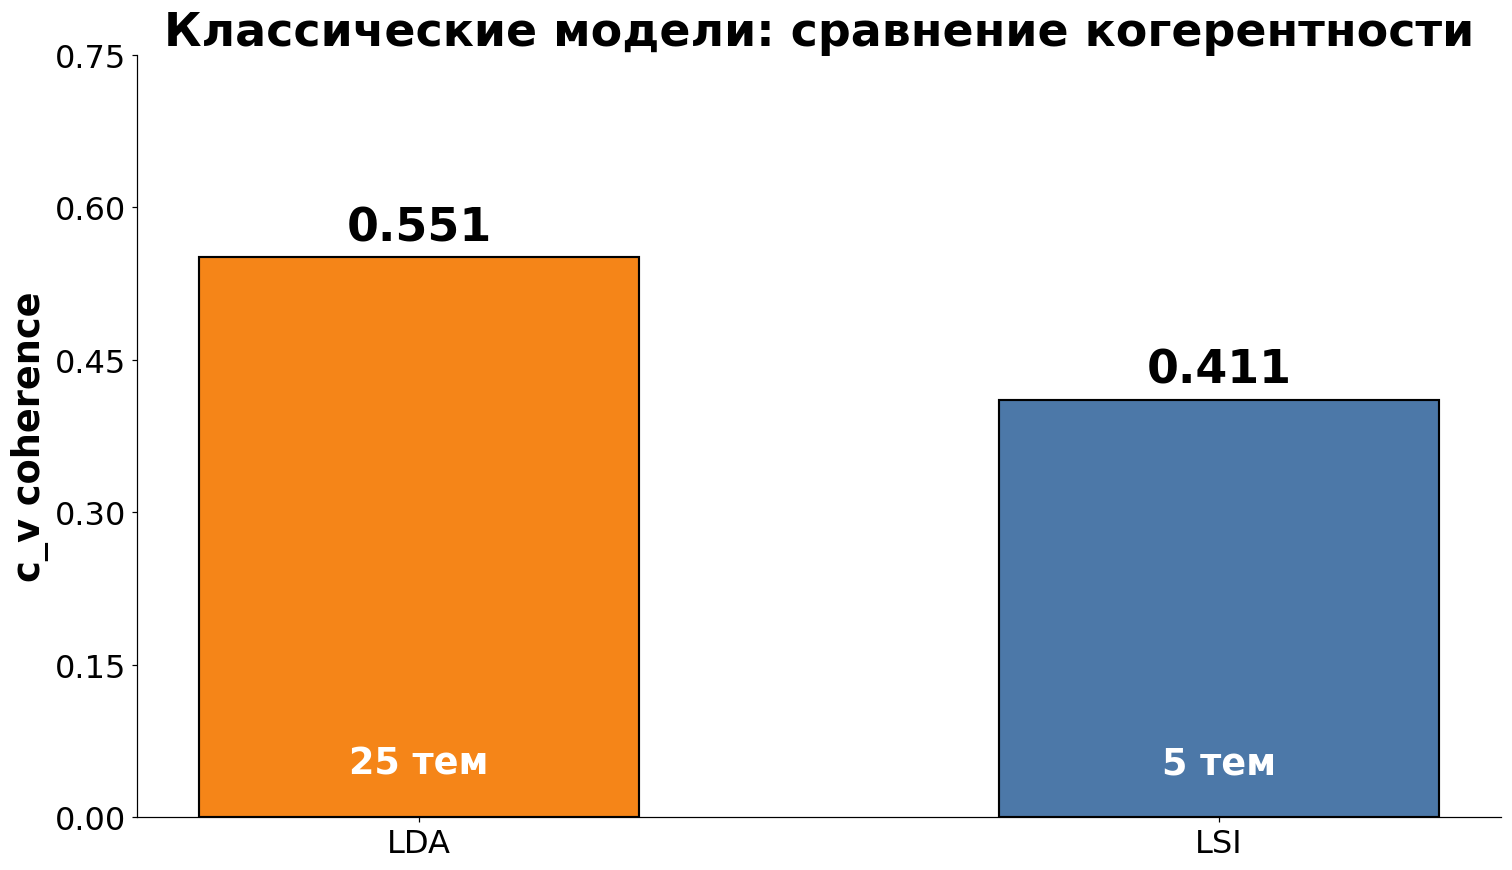

In [ ]:
# Вертикальная диаграмма: LDA vs LSI по c_v coherence.
plot_df = metrics_df[metrics_df["model"].isin(["LSI", "LDA"])].copy()
plot_df = plot_df.sort_values("coherence_cv", ascending=False)

fig, ax = plt.subplots(figsize=(16, 9))
bars = ax.bar(
    plot_df["model"].astype(str),
    plot_df["coherence_cv"],
    color=[COLORS[m] for m in plot_df["model"].astype(str)],
    edgecolor="black",
    linewidth=1.4,
    width=0.55,
)

annotate_bars(ax, bars, fmt="{:.3f}", fontsize=30)
for bar, (_, row) in zip(bars, plot_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        0.035,
        f"{int(row['num_topics'])} тем",
        ha="center",
        va="bottom",
        fontsize=24,
        color="white",
        fontweight="bold",
    )

ax.set_title("Классические модели: сравнение когерентности")
ax.set_ylabel("c_v coherence")
ax.set_xlabel("")
ax.set_ylim(0, max(plot_df["coherence_cv"].max() * 1.20, 0.75))
ax.yaxis.set_major_locator(MaxNLocator(6))
ax.grid(axis="y")
ax.grid(axis="x", visible=False)

save_figure(
    "01_coherence_lda_lsi.png",
    "Классические модели: LDA vs LSI по c_v coherence",
    "Вертикальная столбчатая диаграмма для защиты",
)
plt.show()

Сохранено: c:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\presentation\02_coherence_bigartm_bertopic.png


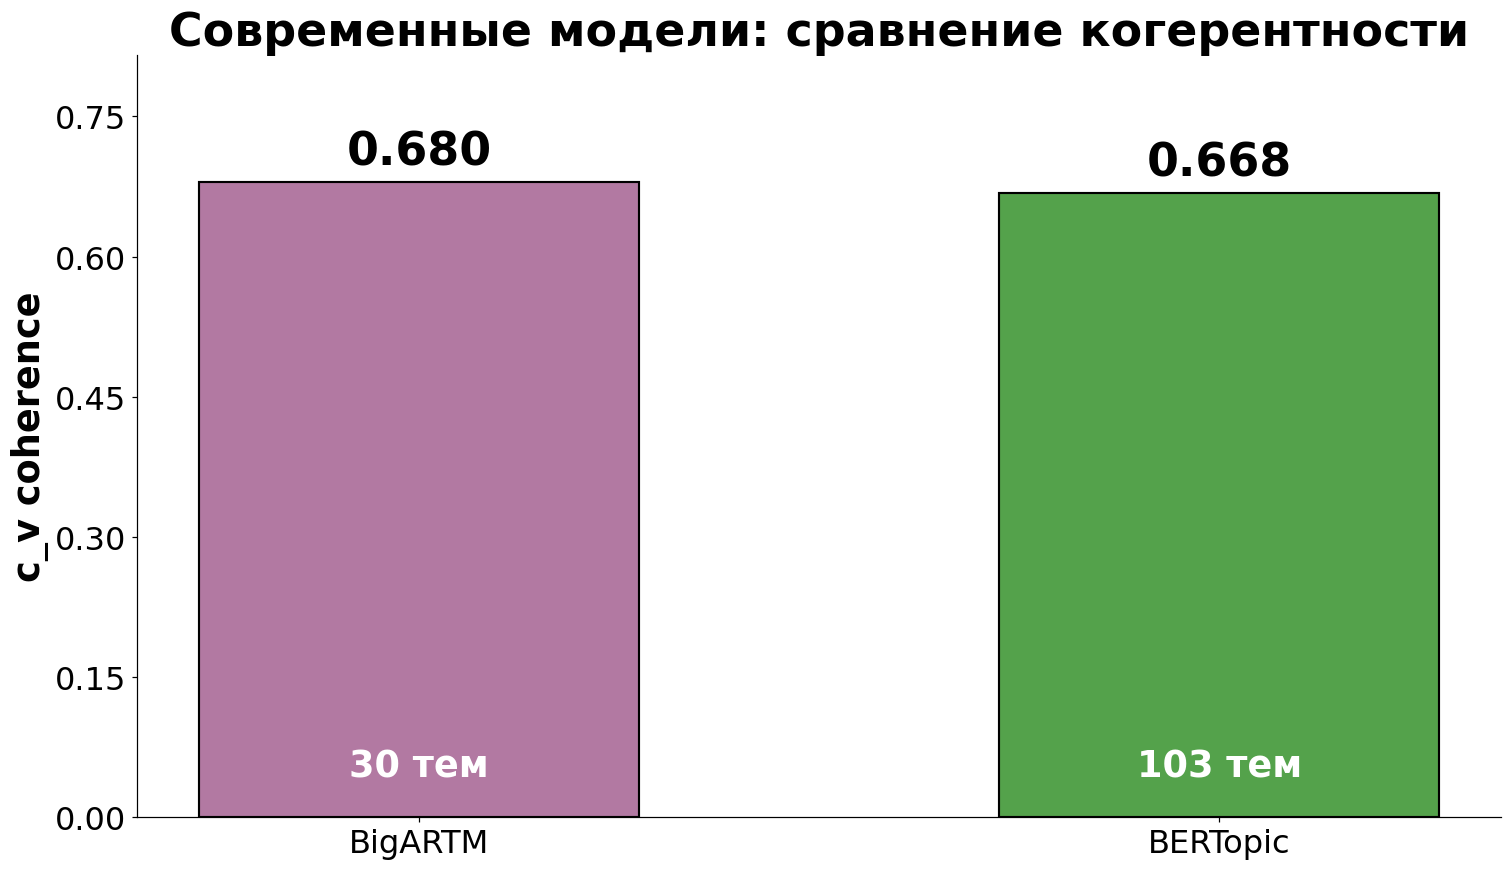

In [ ]:
# BigARTM vs BERTopic по c_v coherence.
plot_df = metrics_df[metrics_df["model"].isin(["BERTopic", "BigARTM"])].copy()
plot_df = plot_df.sort_values("coherence_cv", ascending=False)

fig, ax = plt.subplots(figsize=(16, 9))
bars = ax.bar(
    plot_df["model"].astype(str),
    plot_df["coherence_cv"],
    color=[COLORS[m] for m in plot_df["model"].astype(str)],
    edgecolor="black",
    linewidth=1.4,
    width=0.55,
)

annotate_bars(ax, bars, fmt="{:.3f}", fontsize=30)
for bar, (_, row) in zip(bars, plot_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        0.035,
        f"{int(row['num_topics'])} тем",
        ha="center",
        va="bottom",
        fontsize=24,
        color="white",
        fontweight="bold",
    )

ax.set_title("Современные модели: сравнение когерентности")
ax.set_ylabel("c_v coherence")
ax.set_xlabel("")
ax.set_ylim(0, max(plot_df["coherence_cv"].max() * 1.20, 0.80))
ax.yaxis.set_major_locator(MaxNLocator(6))
ax.grid(axis="y")
ax.grid(axis="x", visible=False)

save_figure(
    "02_coherence_bigartm_bertopic.png",
    "Современные модели: BigARTM vs BERTopic по c_v coherence",
    "Вертикальная столбчатая диаграмма для защиты",
)
plt.show()

Сохранено: c:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\presentation\03_all_models_coherence.png


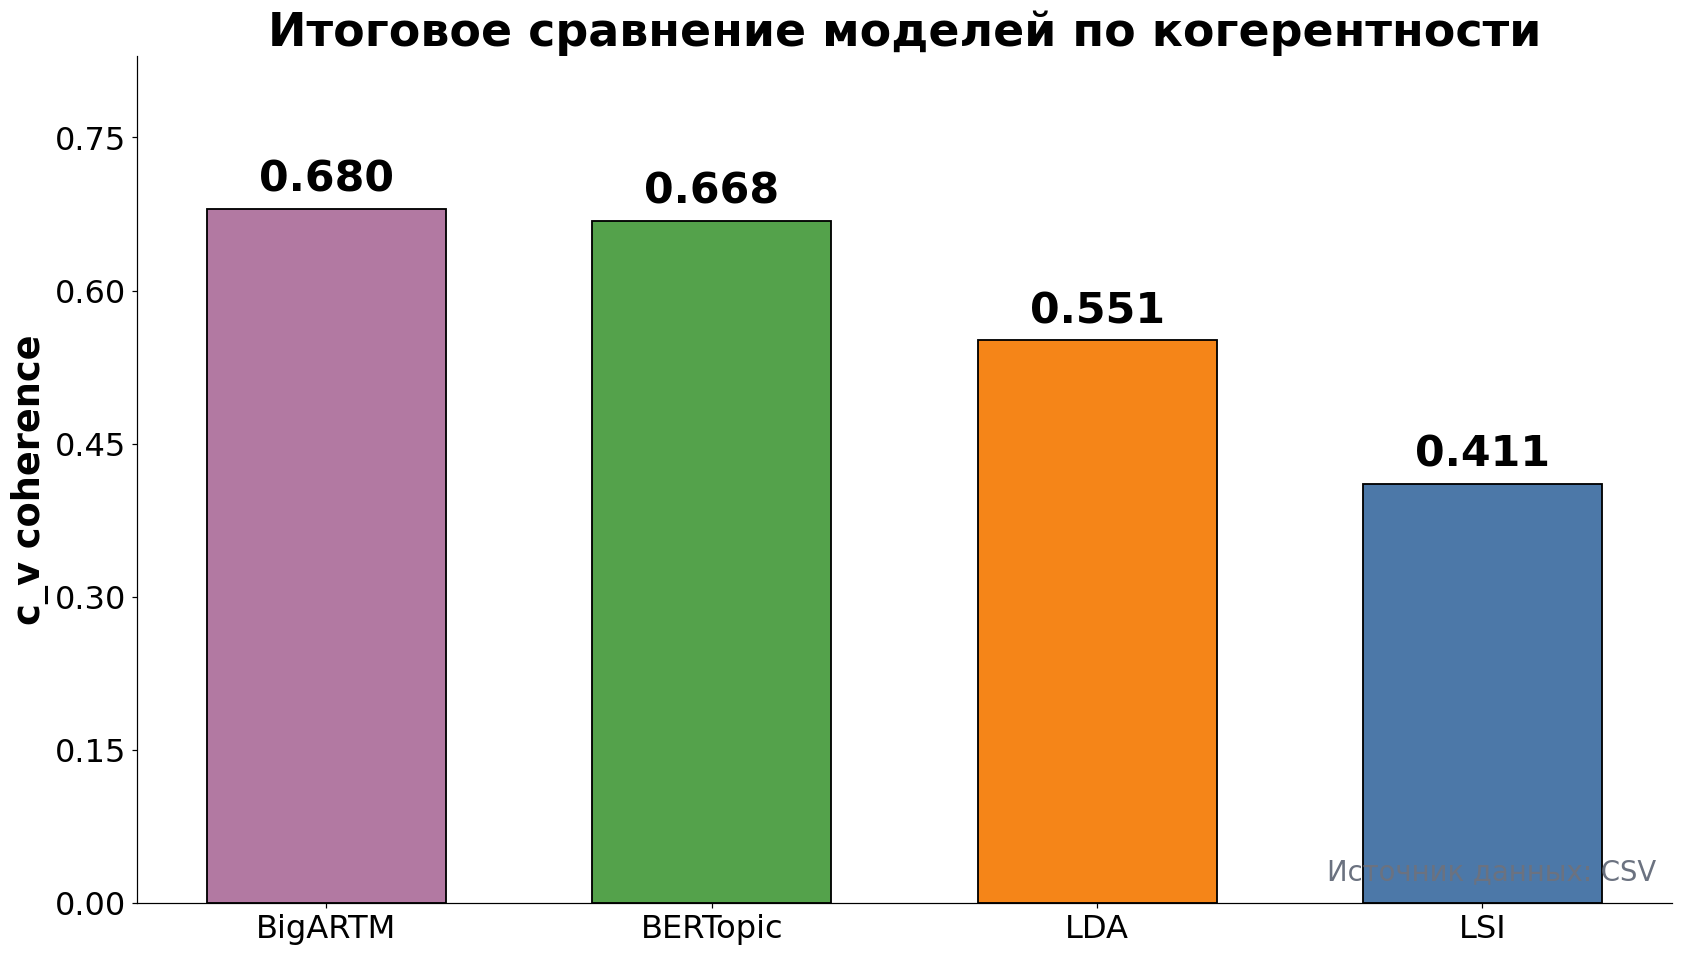

In [ ]:
# Все модели на одном слайде: c_v coherence.
plot_df = metrics_df.copy().sort_values("coherence_cv", ascending=False)

fig, ax = plt.subplots(figsize=(18, 10))
bars = ax.bar(
    plot_df["model"].astype(str),
    plot_df["coherence_cv"],
    color=[COLORS.get(m, COLORS["gray"]) for m in plot_df["model"].astype(str)],
    edgecolor="black",
    linewidth=1.2,
    width=0.62,
)
annotate_bars(ax, bars, fmt="{:.3f}", fontsize=28)

ax.set_title("Итоговое сравнение моделей по когерентности")
ax.set_ylabel("c_v coherence")
ax.set_xlabel("")
ax.set_ylim(0, max(plot_df["coherence_cv"].max() * 1.22, 0.80))
ax.yaxis.set_major_locator(MaxNLocator(6))
ax.grid(axis="y")
ax.grid(axis="x", visible=False)

# Подпись источника данных: полезно, чтобы не перепутать CSV и fallback.
source_text = "CSV" if (plot_df["source"] == "csv").any() else "fallback-значения"
ax.text(
    0.99, 0.02,
    f"Источник данных: {source_text}",
    ha="right", va="bottom",
    fontsize=18,
    color=COLORS["gray"],
    transform=ax.transAxes,
)

save_figure(
    "03_all_models_coherence.png",
    "Все модели: сравнение c_v coherence",
    "Общий график для вывода о лучшем качестве современных моделей",
)
plt.show()

Сохранено: c:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\presentation\04_num_topics_comparison.png


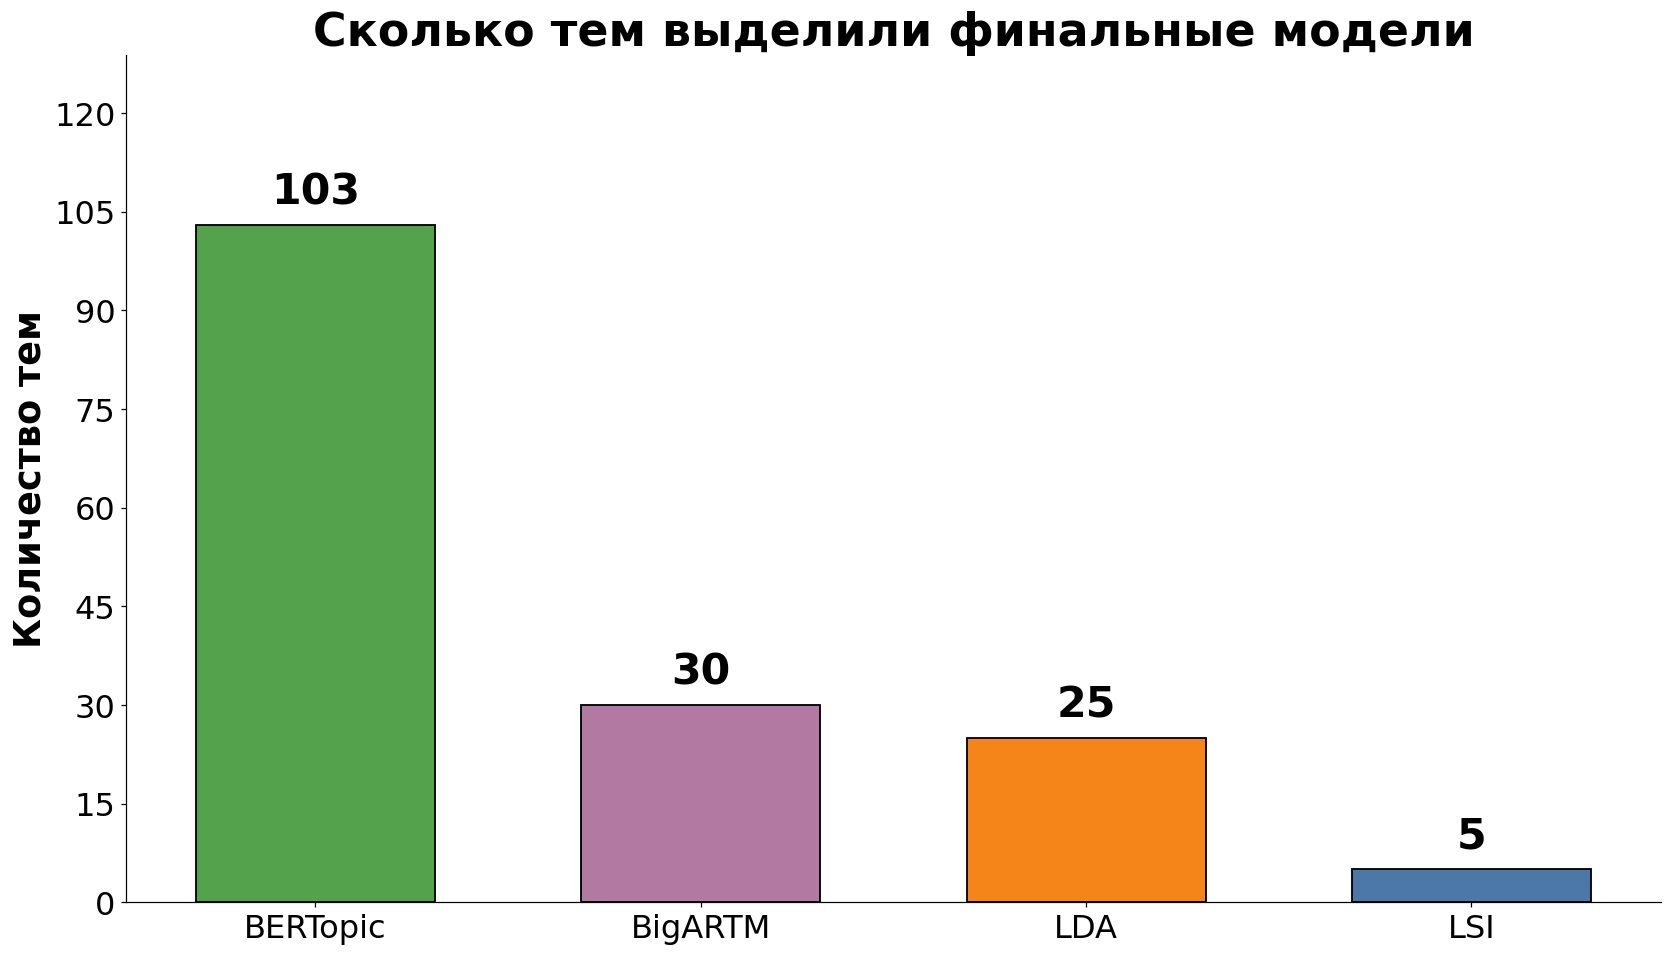

In [ ]:
# График 4. Число тем в финальных моделях.
plot_df = metrics_df.dropna(subset=["num_topics"]).copy()
plot_df = plot_df.sort_values("num_topics", ascending=False)

fig, ax = plt.subplots(figsize=(18, 10))
bars = ax.bar(
    plot_df["model"].astype(str),
    plot_df["num_topics"],
    color=[COLORS.get(m, COLORS["gray"]) for m in plot_df["model"].astype(str)],
    edgecolor="black",
    linewidth=1.2,
    width=0.62,
)

annotate_bars(ax, bars, fmt="{:.0f}", fontsize=28, dy=0.018)

ax.set_title("Сколько тем выделили финальные модели")
ax.set_ylabel("Количество тем")
ax.set_xlabel("")
ax.set_ylim(0, plot_df["num_topics"].max() * 1.25)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis="y")
ax.grid(axis="x", visible=False)

save_figure(
    "04_num_topics_comparison.png",
    "Сравнение числа тем в финальных моделях",
    "Помогает объяснить, почему BERTopic выделил много кластеров, а BigARTM управляемее",
)
plt.show()

Сохранено: c:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\presentation\05_lsi_topics_search.png


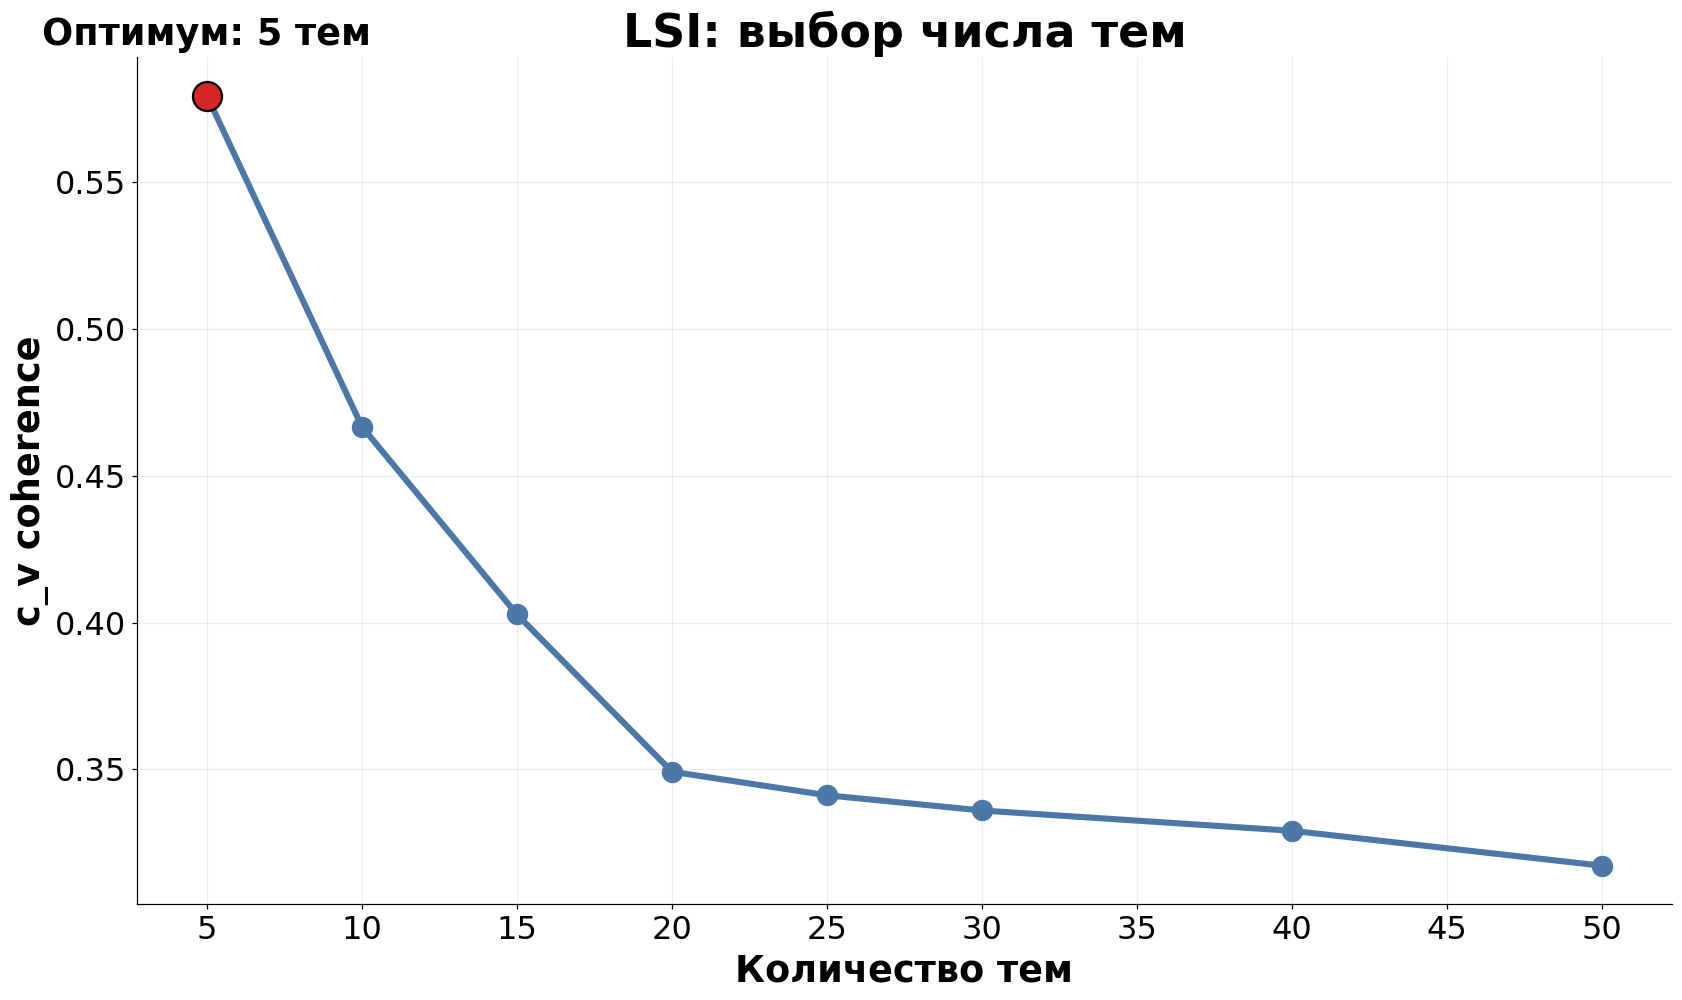

In [ ]:
# График 5. Оптимизация LSI: выбор числа тем.
lsi_opt = read_csv_if_exists(OUTPUT_DIR / "lsi_optimization_results.csv")
if lsi_opt is not None and {"num_topics", "coherence"}.issubset(lsi_opt.columns):
    lsi_plot = lsi_opt.sort_values("num_topics")
    best = lsi_opt.sort_values("coherence", ascending=False).iloc[0]

    fig, ax = plt.subplots(figsize=(18, 10))
    ax.plot(
        lsi_plot["num_topics"],
        lsi_plot["coherence"],
        marker="o",
        linewidth=4,
        markersize=13,
        color=COLORS["LSI"],
    )
    ax.scatter(
        [best["num_topics"]],
        [best["coherence"]],
        s=360,
        color="#D62728",
        edgecolor="black",
        linewidth=1.5,
        zorder=5,
    )
    ax.text(
        best["num_topics"],
        best["coherence"] + max(lsi_plot["coherence"]) * 0.025,
        f"Оптимум: {int(best['num_topics'])} тем",
        ha="center",
        va="bottom",
        fontsize=24,
        fontweight="bold",
    )

    ax.set_title("LSI: выбор числа тем")
    ax.set_xlabel("Количество тем")
    ax.set_ylabel("c_v coherence")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(6))
    ax.grid(True)

    save_figure(
        "05_lsi_topics_search.png",
        "LSI: выбор числа тем по c_v coherence",
        "Используется файл lsi_optimization_results.csv",
    )
    plt.show()
else:
    display(Markdown("**LSI-график оптимизации пропущен:** не найден `outputs/lsi_optimization_results.csv` с колонками `num_topics`, `coherence`."))

Сохранено: c:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\presentation\06_lda_topics_search.png


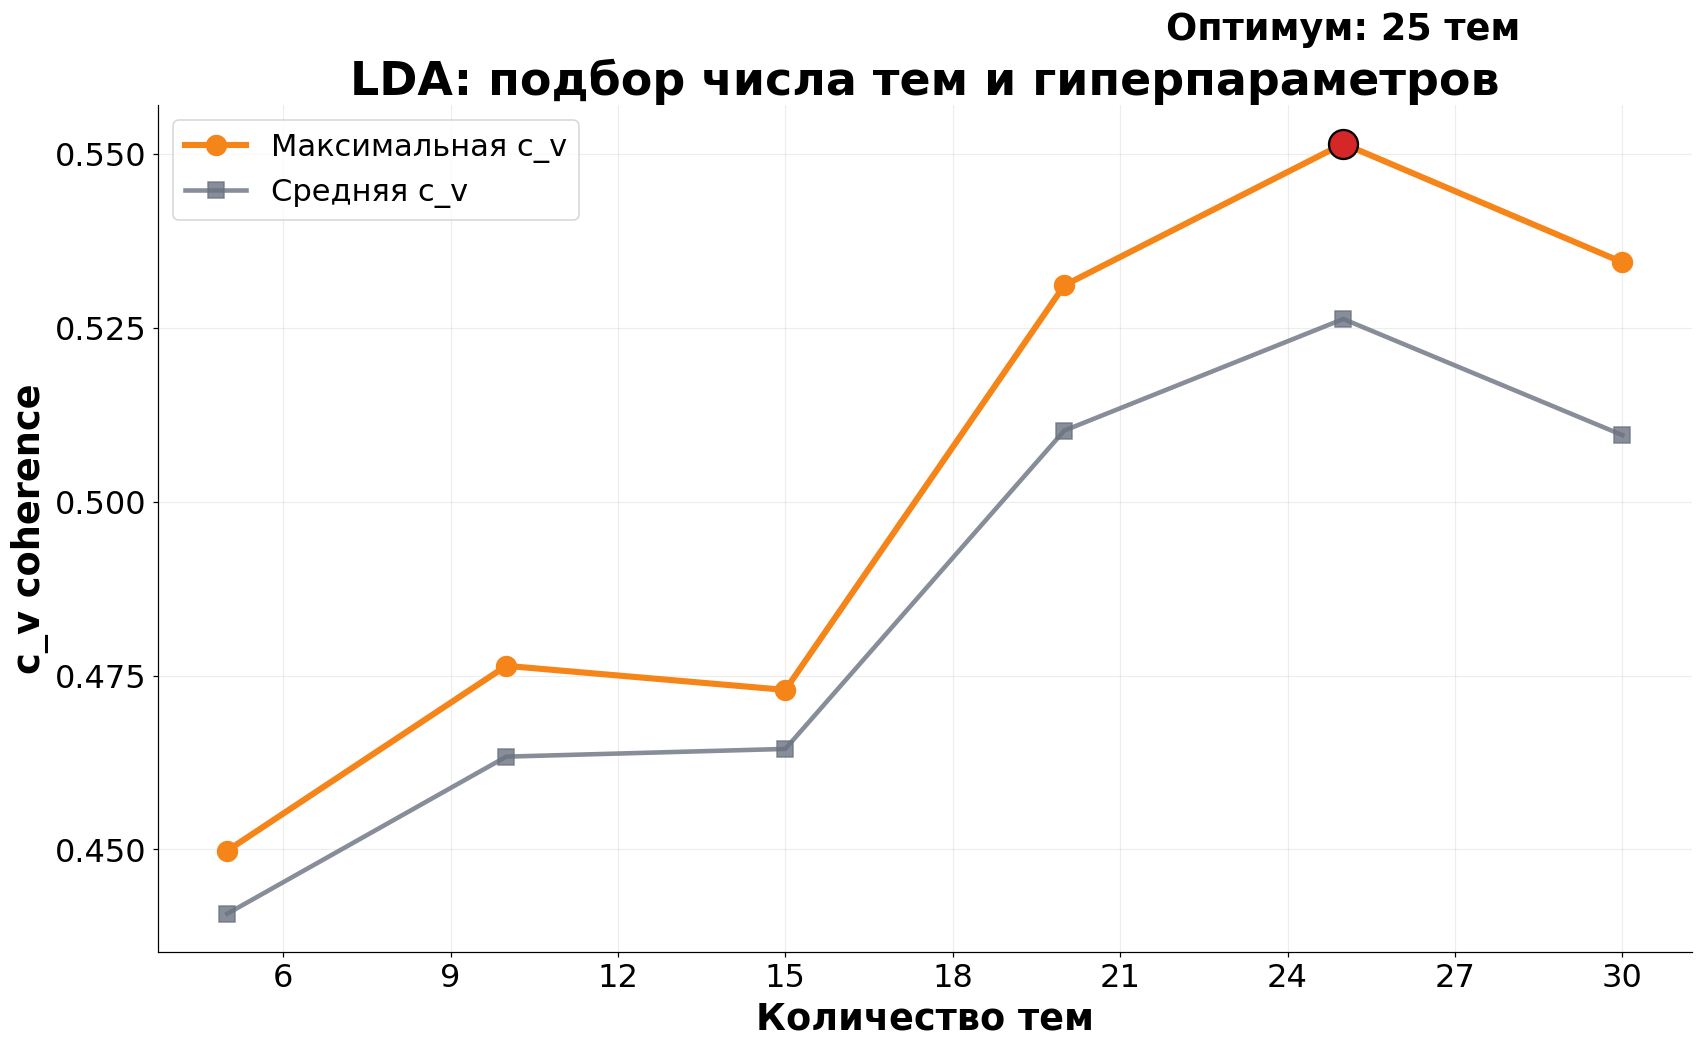

In [ ]:
# Оптимизация LDA: максимальная когерентность по числу тем.
lda_opt = read_csv_if_exists(OUTPUT_DIR / "lda_optimization_results.csv")
if lda_opt is not None and {"num_topics", "coherence"}.issubset(lda_opt.columns):
    lda_group = (
        lda_opt.groupby("num_topics", as_index=False)
        .agg(max_coherence=("coherence", "max"), mean_coherence=("coherence", "mean"))
        .sort_values("num_topics")
    )
    best = lda_group.sort_values("max_coherence", ascending=False).iloc[0]

    fig, ax = plt.subplots(figsize=(18, 10))
    ax.plot(
        lda_group["num_topics"],
        lda_group["max_coherence"],
        marker="o",
        linewidth=4,
        markersize=13,
        color=COLORS["LDA"],
        label="Максимальная c_v",
    )
    ax.plot(
        lda_group["num_topics"],
        lda_group["mean_coherence"],
        marker="s",
        linewidth=3,
        markersize=10,
        color=COLORS["gray"],
        alpha=0.8,
        label="Средняя c_v",
    )
    ax.scatter(
        [best["num_topics"]],
        [best["max_coherence"]],
        s=360,
        color="#D62728",
        edgecolor="black",
        linewidth=1.5,
        zorder=5,
    )
    ax.text(
        best["num_topics"],
        best["max_coherence"] + max(lda_group["max_coherence"]) * 0.025,
        f"Оптимум: {int(best['num_topics'])} тем",
        ha="center",
        va="bottom",
        fontsize=24,
        fontweight="bold",
    )

    ax.set_title("LDA: подбор числа тем и гиперпараметров")
    ax.set_xlabel("Количество тем")
    ax.set_ylabel("c_v coherence")
    ax.legend(loc="best")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(6))
    ax.grid(True)

    save_figure(
        "06_lda_topics_search.png",
        "LDA: оптимизация по c_v coherence",
        "Используется файл lda_optimization_results.csv",
    )
    plt.show()
else:
    display(Markdown("**LDA-график оптимизации пропущен:** не найден `outputs/lda_optimization_results.csv` с колонками `num_topics`, `coherence`."))

Сохранено: c:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\presentation\07_bigartm_topics_search.png


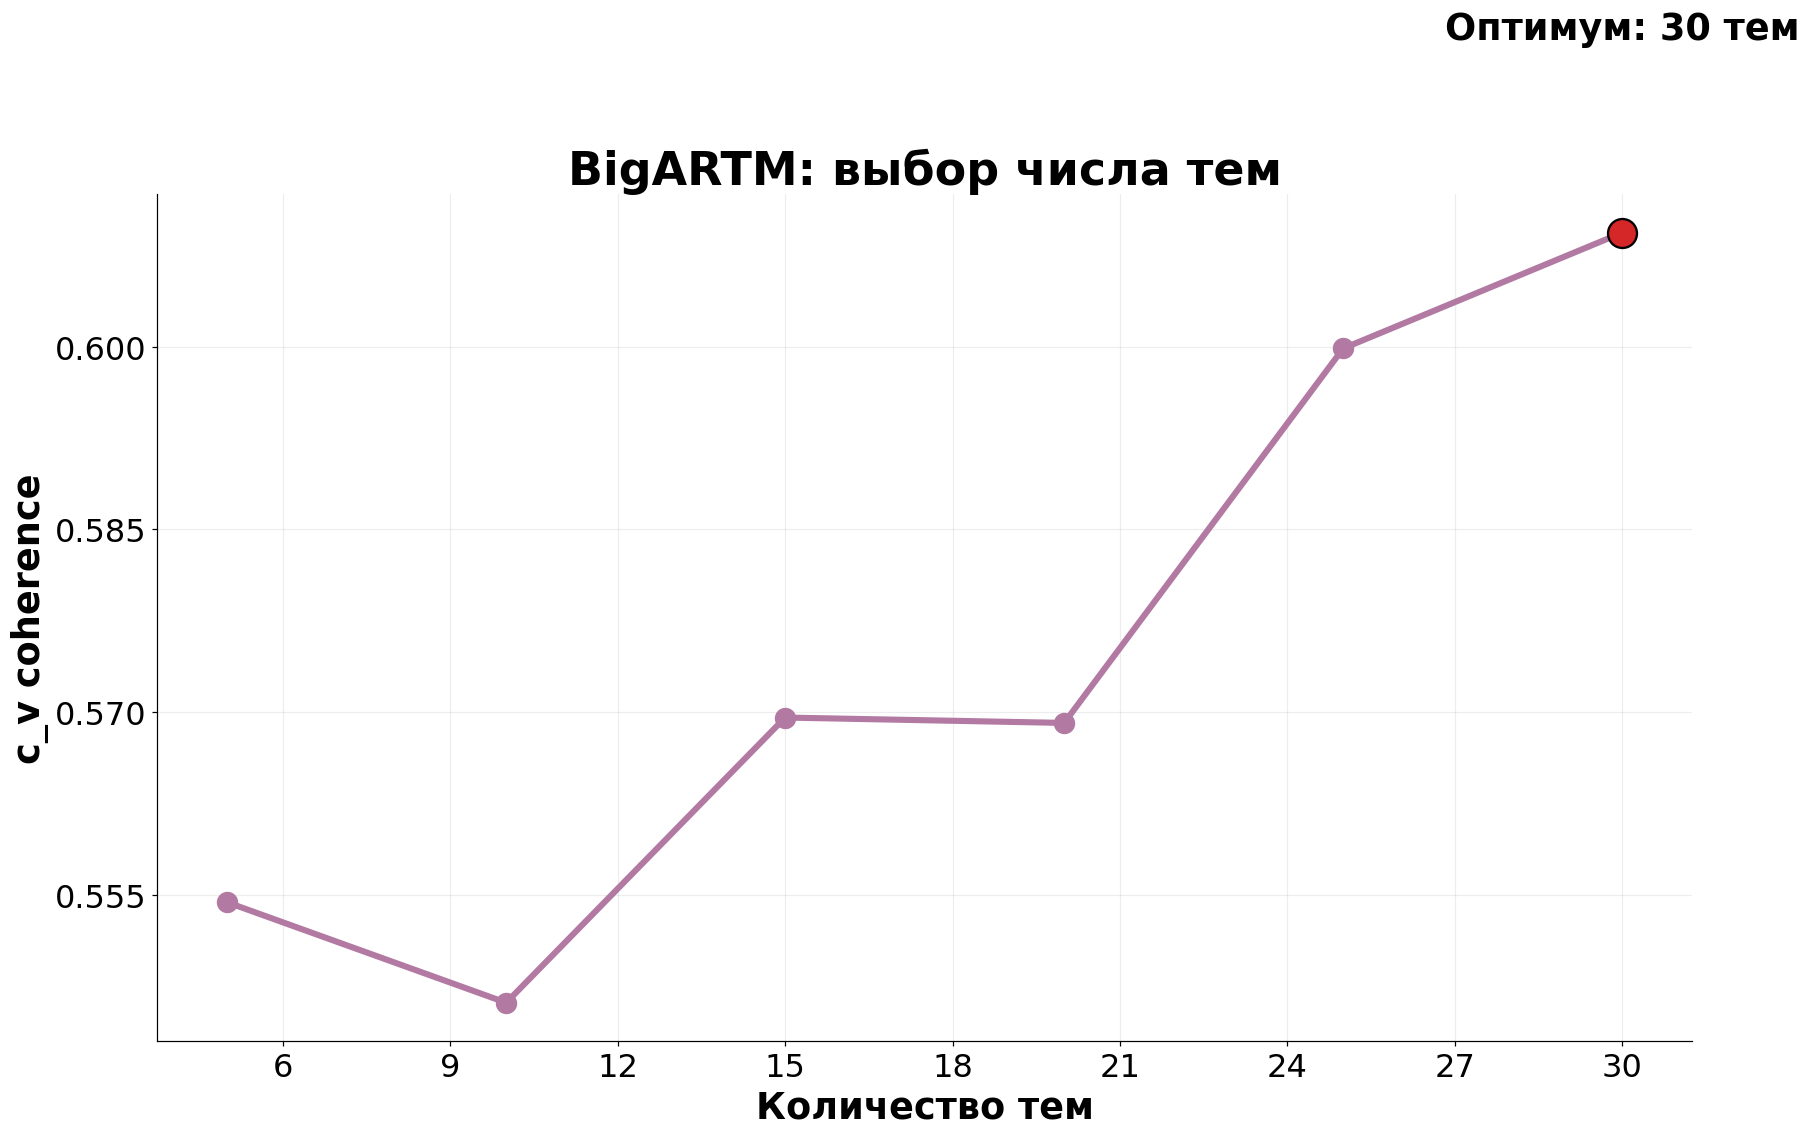

In [ ]:
# BigARTM: выбор числа тем.

bigartm_topics = read_csv_if_exists(OUTPUT_DIR / "bigartm_topics_search.csv")
if bigartm_topics is not None and {"num_topics", "coherence"}.issubset(bigartm_topics.columns):
    plot_df = bigartm_topics.sort_values("num_topics")
    best = bigartm_topics.sort_values("coherence", ascending=False).iloc[0]

    fig, ax = plt.subplots(figsize=(18, 10))
    ax.plot(
        plot_df["num_topics"],
        plot_df["coherence"],
        marker="o",
        linewidth=4,
        markersize=13,
        color=COLORS["BigARTM"],
    )
    ax.scatter(
        [best["num_topics"]],
        [best["coherence"]],
        s=360,
        color="#D62728",
        edgecolor="black",
        linewidth=1.5,
        zorder=5,
    )
    ax.text(
        best["num_topics"],
        best["coherence"] + max(plot_df["coherence"]) * 0.025,
        f"Оптимум: {int(best['num_topics'])} тем",
        ha="center",
        va="bottom",
        fontsize=24,
        fontweight="bold",
    )

    ax.set_title("BigARTM: выбор числа тем")
    ax.set_xlabel("Количество тем")
    ax.set_ylabel("c_v coherence")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(6))
    ax.grid(True)

    save_figure(
        "07_bigartm_topics_search.png",
        "BigARTM: выбор числа тем",
        "Используется файл bigartm_topics_search.csv",
    )
    plt.show()
else:
    display(Markdown("**BigARTM-график выбора числа тем пропущен:** не найден `outputs/bigartm_topics_search.csv` с колонками `num_topics`, `coherence`."))

Сохранено: c:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\presentation\08_bigartm_regularization_top.png


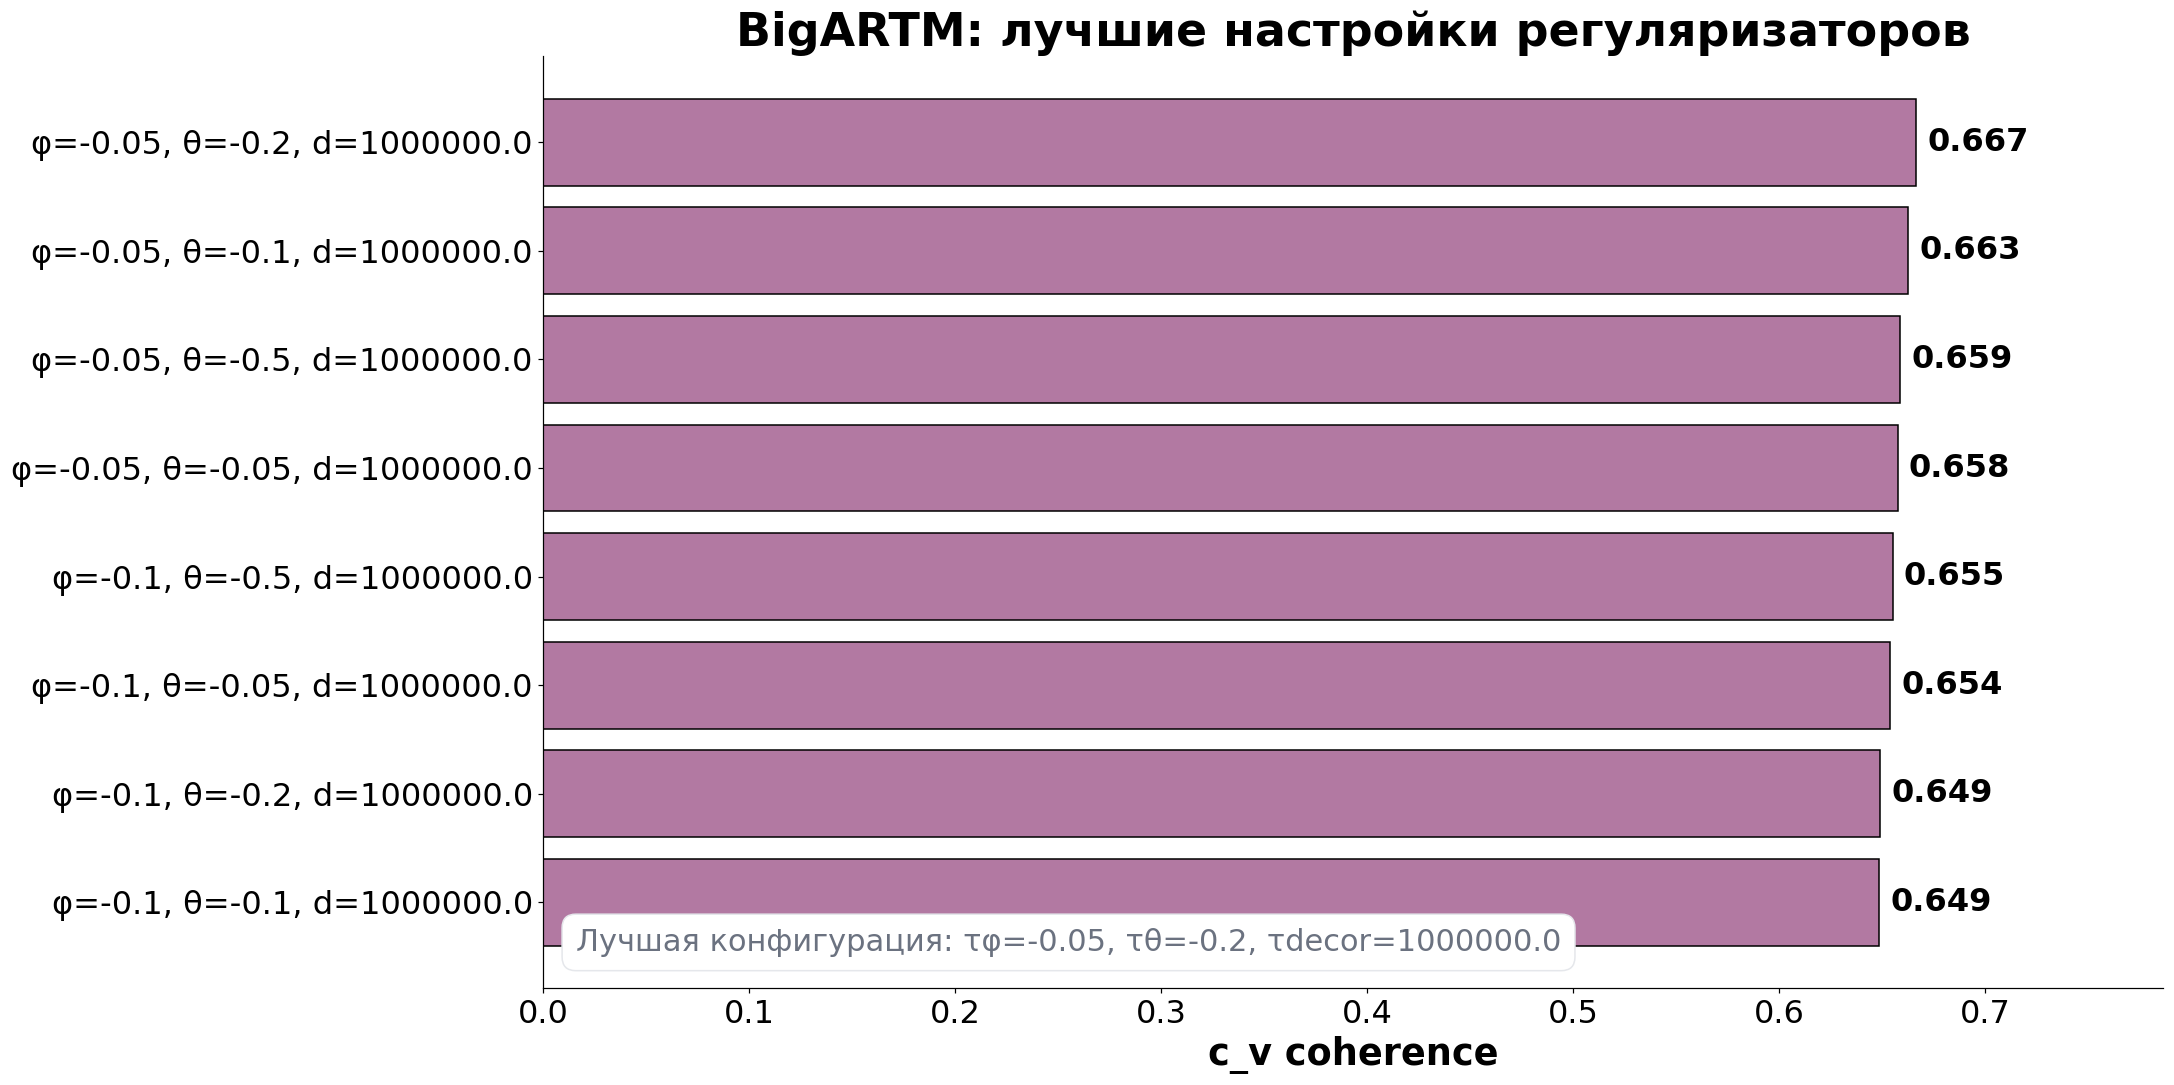

In [ ]:
# BigARTM: влияние регуляризаторов на когерентность.
reg_df = read_csv_if_exists(OUTPUT_DIR / "bigartm_regularization_search.csv")
required = {"tau_phi", "tau_theta", "tau_decorr", "coherence"}
if reg_df is not None and required.issubset(reg_df.columns):
    best = reg_df.sort_values("coherence", ascending=False).iloc[0]

    top_reg = reg_df.sort_values("coherence", ascending=False).head(8).copy()
    top_reg["config"] = [
        f"φ={r.tau_phi}, θ={r.tau_theta}, d={r.tau_decorr}"
        for r in top_reg.itertuples()
    ]
    top_reg = top_reg.iloc[::-1]

    fig, ax = plt.subplots(figsize=(19, 11))
    bars = ax.barh(
        top_reg["config"],
        top_reg["coherence"],
        color=COLORS["BigARTM"],
        edgecolor="black",
        linewidth=1.0,
    )

    for bar in bars:
        w = bar.get_width()
        ax.text(
            w + top_reg["coherence"].max() * 0.008,
            bar.get_y() + bar.get_height() / 2,
            f"{w:.3f}",
            va="center",
            fontsize=21,
            fontweight="bold",
        )

    ax.set_title("BigARTM: лучшие настройки регуляризаторов")
    ax.set_xlabel("c_v coherence")
    ax.set_ylabel("")
    ax.set_xlim(0, top_reg["coherence"].max() * 1.18)
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)

    ax.text(
        0.02, 0.04,
        f"Лучшая конфигурация: τφ={best['tau_phi']}, τθ={best['tau_theta']}, τdecor={best['tau_decorr']}",
        transform=ax.transAxes,
        fontsize=20,
        color=COLORS["gray"],
        bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor=COLORS["light_gray"]),
    )

    save_figure(
        "08_bigartm_regularization_top.png",
        "BigARTM: лучшие регуляризаторы",
        "Используется файл bigartm_regularization_search.csv",
    )
    plt.show()
else:
    display(Markdown("**BigARTM-график регуляризаторов пропущен:** не найден `outputs/bigartm_regularization_search.csv` с нужными колонками."))

Сохранено: c:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\presentation\09_bertopic_largest_topics.png


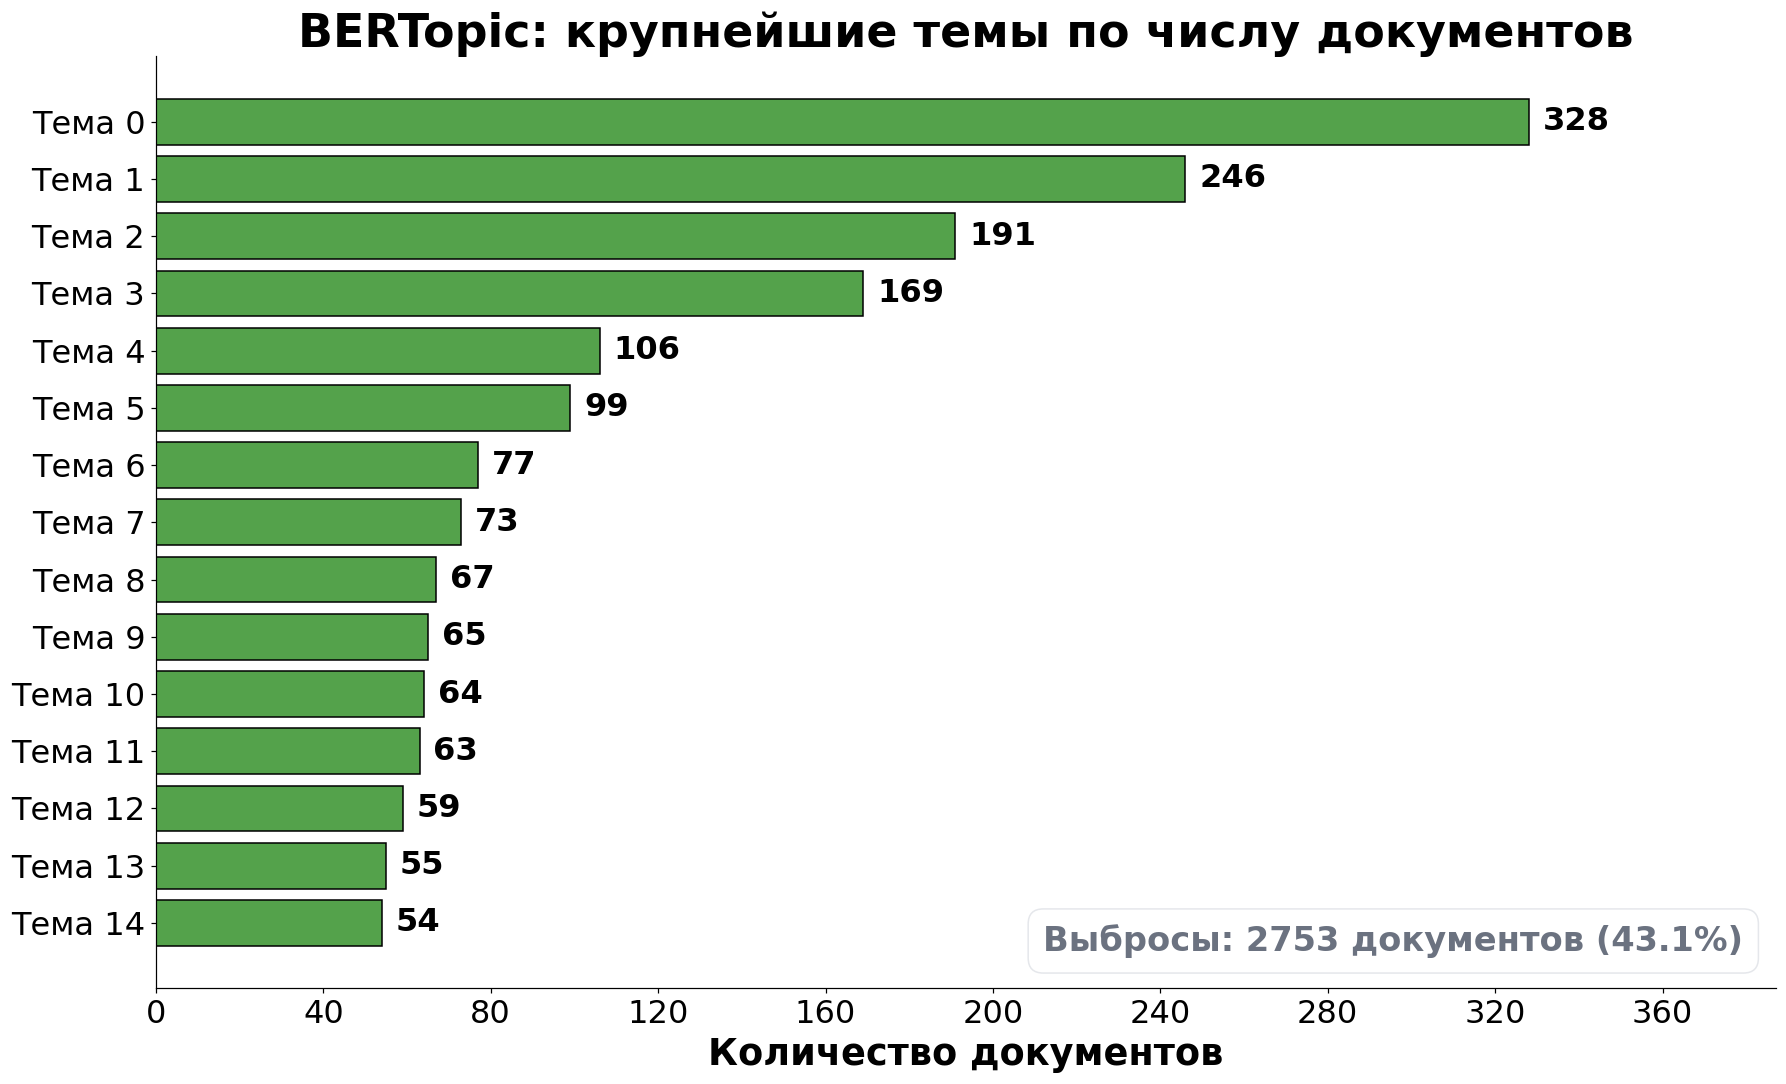

In [ ]:
# BERTopic: распределение документов по самым крупным темам.
bertopic_docs = read_csv_if_exists(OUTPUT_DIR / "documents_with_topics.csv")
if bertopic_docs is not None and "topic" in bertopic_docs.columns:
    counts = bertopic_docs["topic"].value_counts().rename_axis("topic").reset_index(name="documents")
    counts["topic"] = counts["topic"].astype(int)

    outliers = int(counts.loc[counts["topic"] == -1, "documents"].sum()) if (counts["topic"] == -1).any() else 0
    total = int(counts["documents"].sum())
    valid_counts = counts[counts["topic"] != -1].sort_values("documents", ascending=False).head(15).copy()
    valid_counts = valid_counts.iloc[::-1]
    valid_counts["label"] = valid_counts["topic"].apply(lambda x: f"Тема {x}")

    fig, ax = plt.subplots(figsize=(19, 11))
    bars = ax.barh(
        valid_counts["label"],
        valid_counts["documents"],
        color=COLORS["BERTopic"],
        edgecolor="black",
        linewidth=1.0,
    )

    for bar in bars:
        w = bar.get_width()
        ax.text(
            w + valid_counts["documents"].max() * 0.01,
            bar.get_y() + bar.get_height()/2,
            f"{int(w)}",
            va="center",
            fontsize=21,
            fontweight="bold",
        )

    ax.set_title("BERTopic: крупнейшие темы по числу документов")
    ax.set_xlabel("Количество документов")
    ax.set_ylabel("")
    ax.set_xlim(0, valid_counts["documents"].max() * 1.18)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)

    if total > 0:
        ax.text(
            0.98, 0.04,
            f"Выбросы: {outliers} документов ({outliers / total:.1%})",
            transform=ax.transAxes,
            ha="right",
            fontsize=22,
            fontweight="bold",
            color=COLORS["gray"],
            bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor=COLORS["light_gray"]),
        )

    save_figure(
        "09_bertopic_largest_topics.png",
        "BERTopic: крупнейшие темы",
        "Используется файл documents_with_topics.csv",
    )
    plt.show()
else:
    display(Markdown("**BERTopic-распределение пропущено:** не найден `outputs/documents_with_topics.csv` с колонкой `topic`."))

Сохранено: c:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\presentation\10_bertopic_outlier_share.png


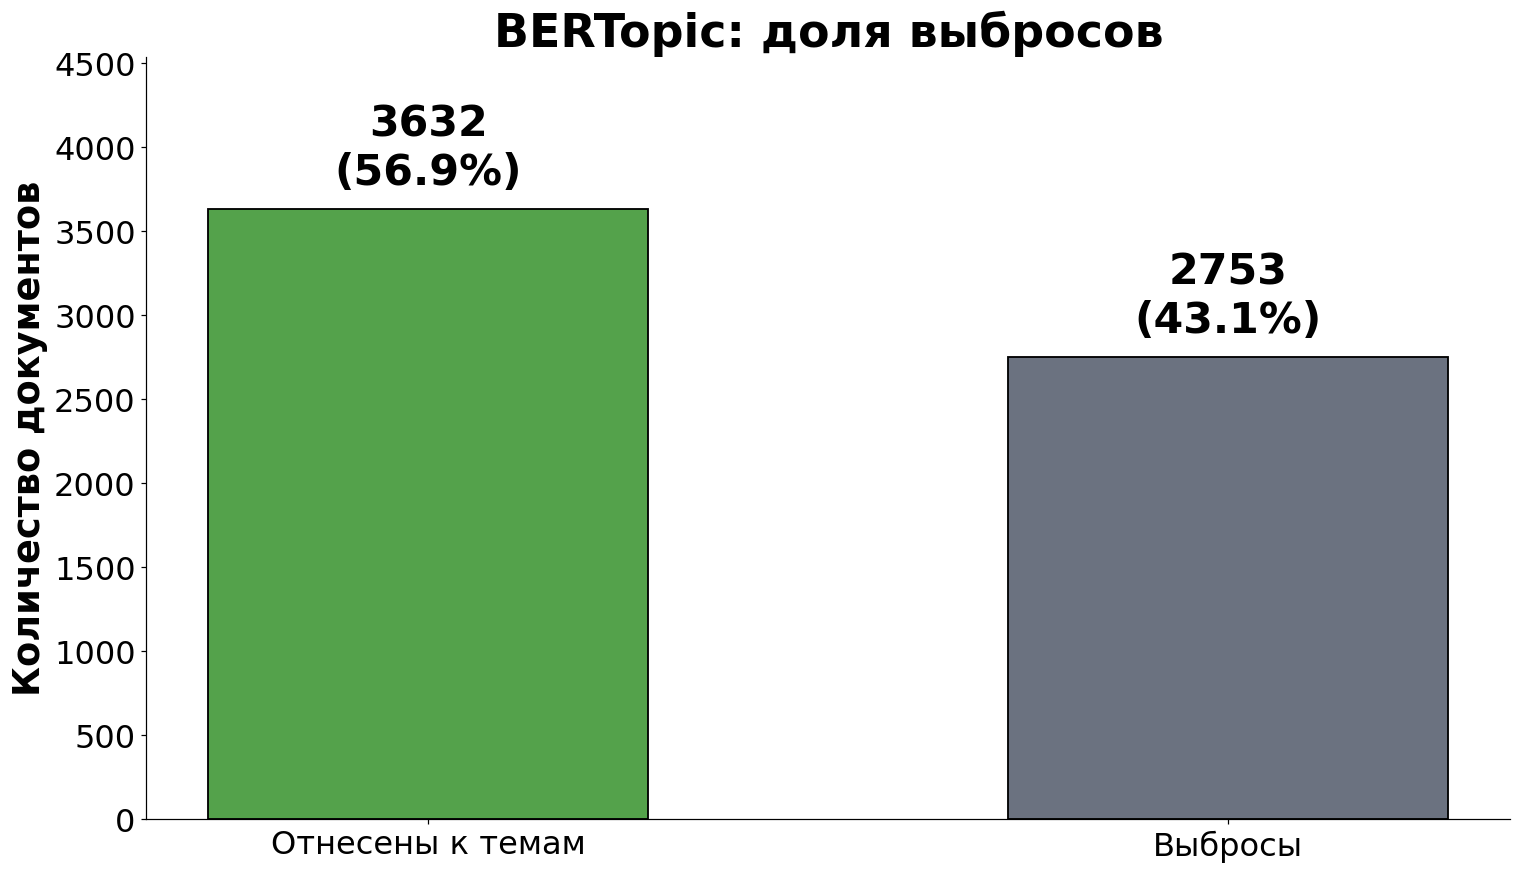

In [ ]:
# BERTopic: доля выбросов и документов, отнесённых к темам.
if bertopic_docs is not None and "topic" in bertopic_docs.columns:
    total = len(bertopic_docs)
    outliers = int((bertopic_docs["topic"] == -1).sum())
    assigned = total - outliers

    fig, ax = plt.subplots(figsize=(16, 9))
    labels = ["Отнесены к темам", "Выбросы"]
    values = [assigned, outliers]
    bars = ax.bar(
        labels,
        values,
        color=[COLORS["BERTopic"], COLORS["gray"]],
        edgecolor="black",
        linewidth=1.2,
        width=0.55,
    )

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(values) * 0.025,
            f"{value}\n({value / total:.1%})",
            ha="center",
            va="bottom",
            fontsize=28,
            fontweight="bold",
        )

    ax.set_title("BERTopic: доля выбросов")
    ax.set_ylabel("Количество документов")
    ax.set_xlabel("")
    ax.set_ylim(0, max(values) * 1.25)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis="y")
    ax.grid(axis="x", visible=False)

    save_figure(
        "10_bertopic_outlier_share.png",
        "BERTopic: документы в темах и выбросы",
        "Показывает ограничение BERTopic на данном корпусе",
    )
    plt.show()
else:
    display(Markdown("**BERTopic-график выбросов пропущен:** нет данных `documents_with_topics.csv`."))

Сохранено: c:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\presentation\11_bigartm_dominant_topics_distribution.png


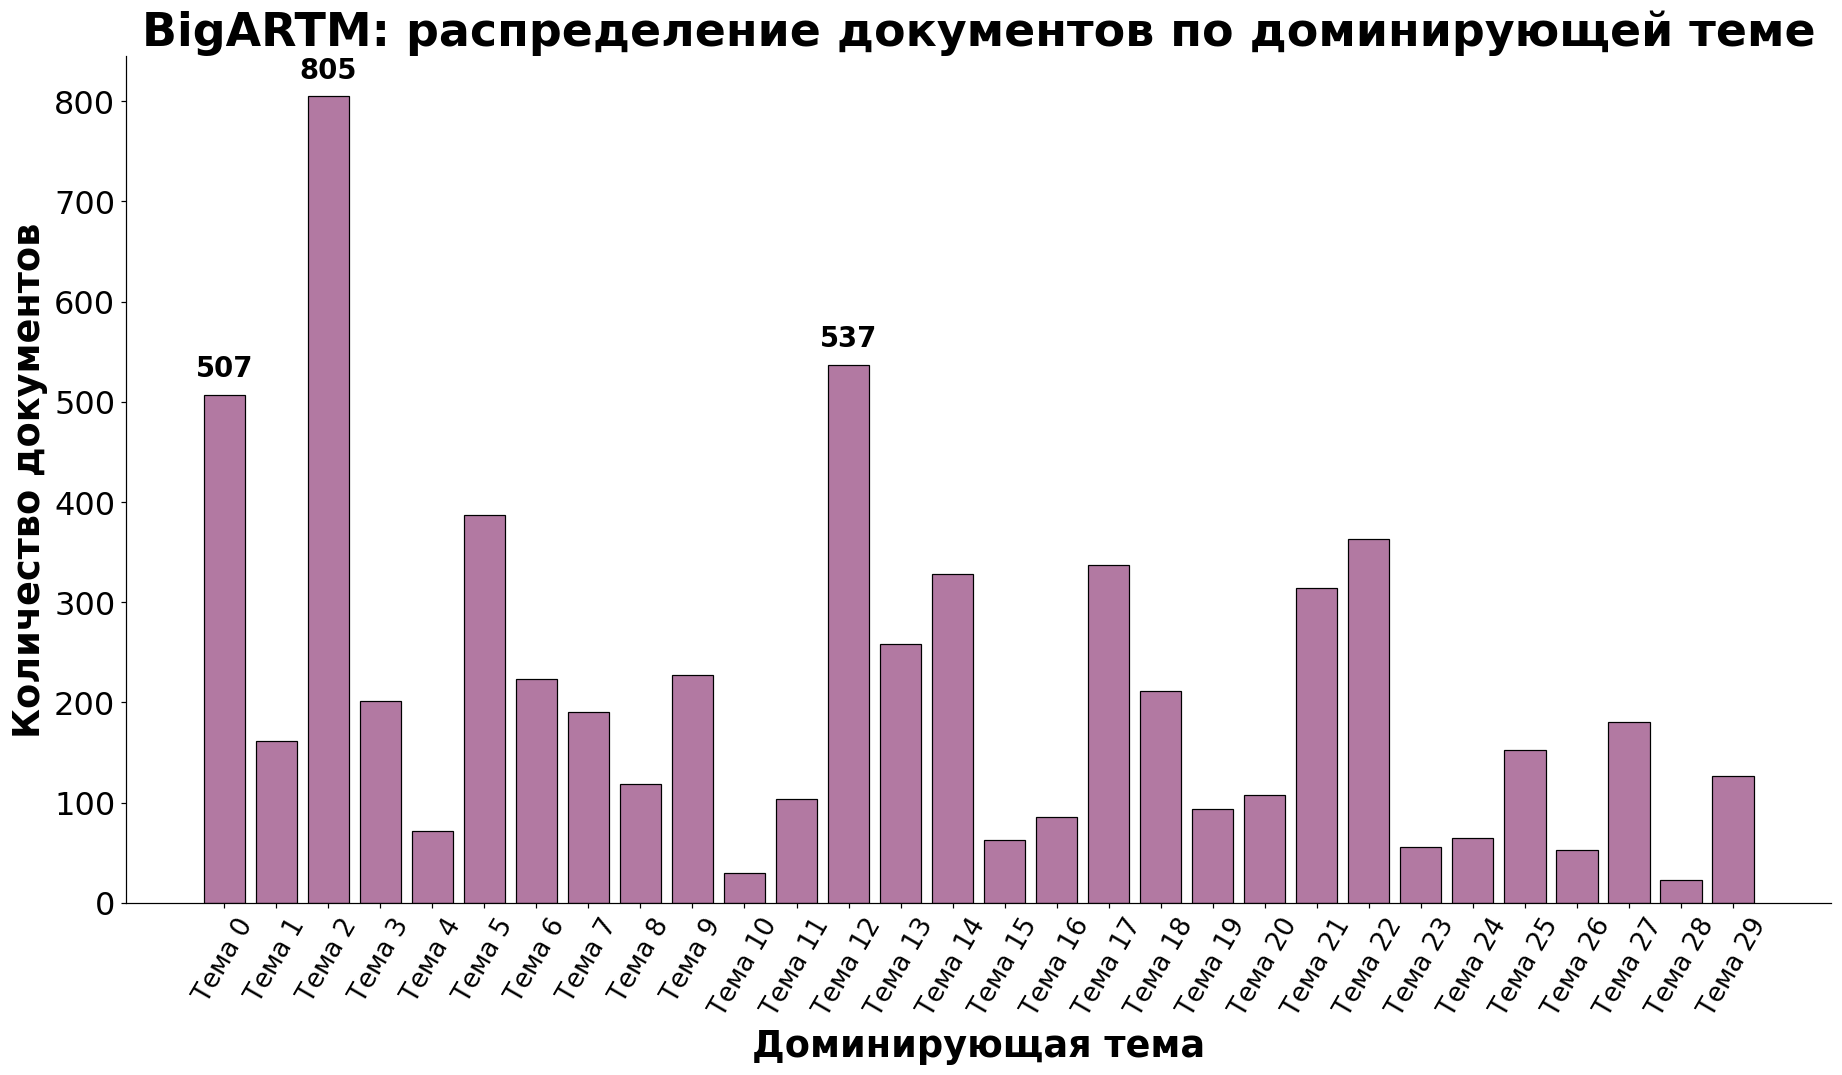

In [ ]:
# BigARTM: распределение документов по доминирующей теме.
bigartm_docs = read_csv_if_exists(OUTPUT_DIR / "bigartm_documents_topics.csv")
if bigartm_docs is not None and "dominant_topic" in bigartm_docs.columns:
    counts = (
        bigartm_docs["dominant_topic"]
        .astype(str)
        .value_counts()
        .rename_axis("topic")
        .reset_index(name="documents")
    )

    import re

    # Сортировка topic_1, topic_2, ... по номеру, если возможно.
    def topic_num(x):
        found = re.findall(r"\d+", str(x))
        return int(found[0]) if found else 9999

    counts["topic_num"] = counts["topic"].apply(topic_num)
    counts = counts.sort_values("topic_num")

    plot_counts = counts.head(35).copy()
    plot_counts["label"] = plot_counts["topic"].apply(lambda x: str(x).replace("topic_", "Тема "))

    fig, ax = plt.subplots(figsize=(20, 10))
    bars = ax.bar(
        plot_counts["label"],
        plot_counts["documents"],
        color=COLORS["BigARTM"],
        edgecolor="black",
        linewidth=0.8,
    )

    ax.set_title("BigARTM: распределение документов по доминирующей теме")
    ax.set_xlabel("Доминирующая тема")
    ax.set_ylabel("Количество документов")
    ax.tick_params(axis="x", rotation=60)
    ax.xaxis.set_tick_params(labelsize=17)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis="y")
    ax.grid(axis="x", visible=False)

    threshold = plot_counts["documents"].max() * 0.55
    for bar in bars:
        h = bar.get_height()
        if h >= threshold:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                h + plot_counts["documents"].max() * 0.015,
                f"{int(h)}",
                ha="center",
                va="bottom",
                fontsize=18,
                fontweight="bold",
            )

    save_figure(
        "11_bigartm_dominant_topics_distribution.png",
        "BigARTM: документы по доминирующей теме",
        "Используется файл bigartm_documents_topics.csv",
    )
    plt.show()
else:
    display(Markdown("**BigARTM-распределение документов пропущено:** не найден `outputs/bigartm_documents_topics.csv` с колонкой `dominant_topic`."))

Сохранено: c:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\presentation\12_documents_assigned_vs_outliers.png


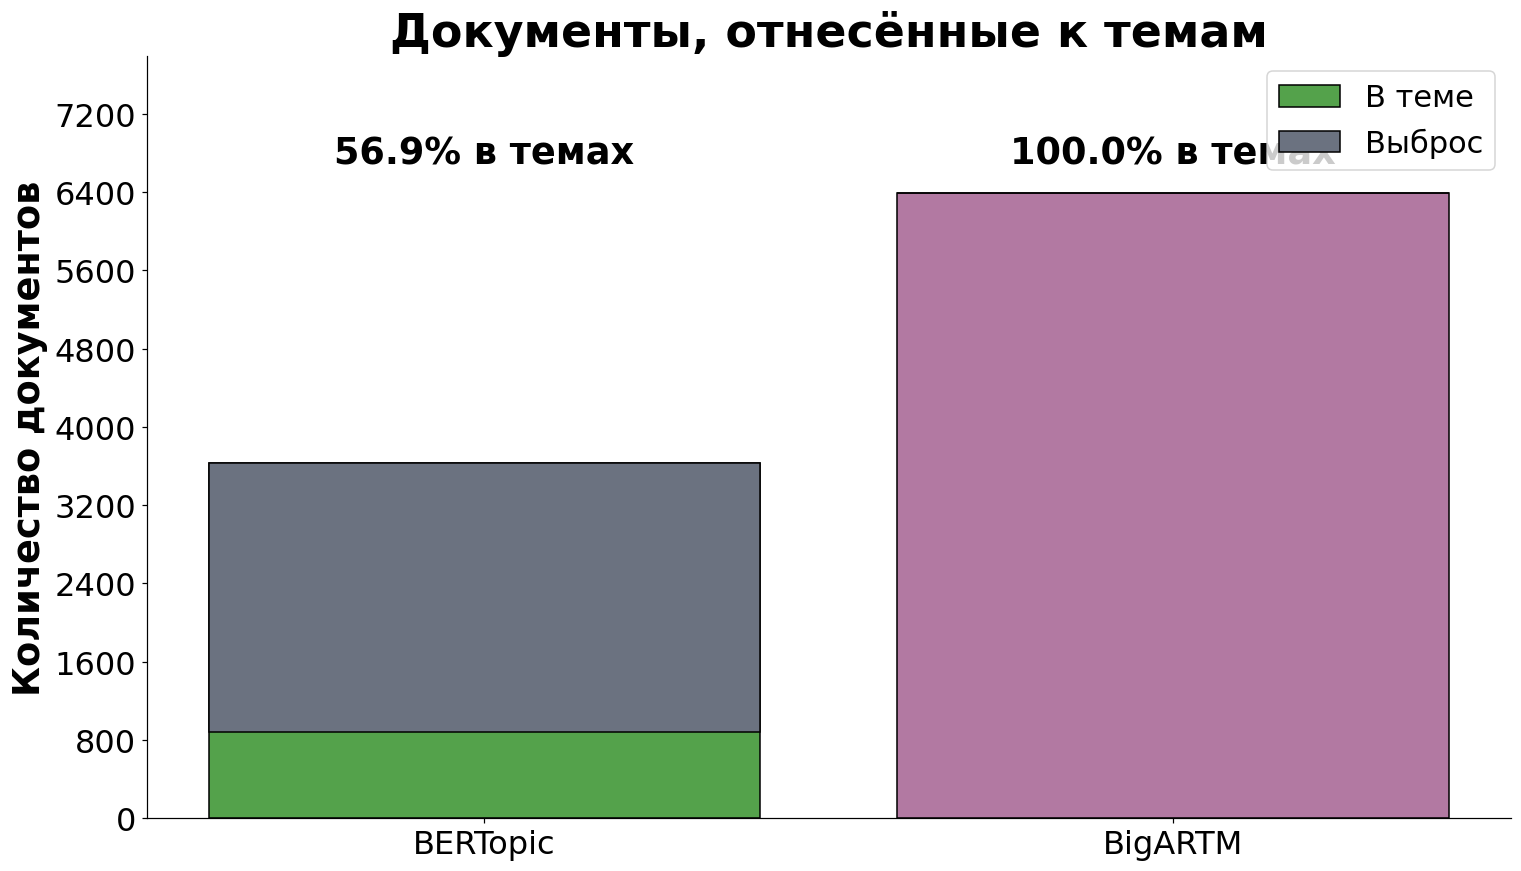

In [ ]:

# Сравнение устойчивости распределения документов:
# BERTopic assigned/outliers + BigARTM все документы с доминирующей темой.
rows = []

if bertopic_docs is not None and "topic" in bertopic_docs.columns:
    rows.append({"model": "BERTopic", "status": "В теме", "documents": int((bertopic_docs["topic"] != -1).sum())})
    rows.append({"model": "BERTopic", "status": "Выброс", "documents": int((bertopic_docs["topic"] == -1).sum())})

if bigartm_docs is not None and "dominant_topic" in bigartm_docs.columns:
    rows.append({"model": "BigARTM", "status": "В теме", "documents": int(bigartm_docs["dominant_topic"].notna().sum())})
    rows.append({"model": "BigARTM", "status": "Выброс", "documents": 0})

if rows:
    cover_df = pd.DataFrame(rows)
    pivot = cover_df.pivot(index="model", columns="status", values="documents").fillna(0)
    for col in ["В теме", "Выброс"]:
        if col not in pivot.columns:
            pivot[col] = 0
    pivot = pivot[["В теме", "Выброс"]]

    fig, ax = plt.subplots(figsize=(16, 9))
    bottom = np.zeros(len(pivot))
    x = np.arange(len(pivot.index))

    bars1 = ax.bar(
        x,
        pivot["В теме"],
        bottom=bottom,
        color=[COLORS.get(m, COLORS["gray"]) for m in pivot.index],
        edgecolor="black",
        linewidth=1.0,
        label="В теме",
    )
    bottom += pivot["В теме"].values
    bars2 = ax.bar(
        x,
        pivot["Выброс"],
        bottom=bottom - pivot["Выброс"].values,
        color=COLORS["gray"],
        edgecolor="black",
        linewidth=1.0,
        label="Выброс",
    )

    totals = pivot.sum(axis=1).values
    for i, total in enumerate(totals):
        if total <= 0:
            continue
        assigned_share = pivot.iloc[i]["В теме"] / total
        ax.text(
            x[i],
            total * 1.035,
            f"{assigned_share:.1%} в темах",
            ha="center",
            va="bottom",
            fontsize=24,
            fontweight="bold",
        )

    ax.set_title("Документы, отнесённые к темам")
    ax.set_ylabel("Количество документов")
    ax.set_xlabel("")
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index)
    ax.set_ylim(0, max(totals) * 1.22)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(loc="upper right")
    ax.grid(axis="y")
    ax.grid(axis="x", visible=False)

    save_figure(
        "12_documents_assigned_vs_outliers.png",
        "BERTopic и BigARTM: документы в темах и выбросы",
        "Показывает практическое отличие BERTopic и BigARTM",
    )
    plt.show()
else:
    display(Markdown("**График покрытия документов пропущен:** нет `documents_with_topics.csv` и `bigartm_documents_topics.csv`."))

Сохранено: c:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\presentation\14_key_results_dashboard.png


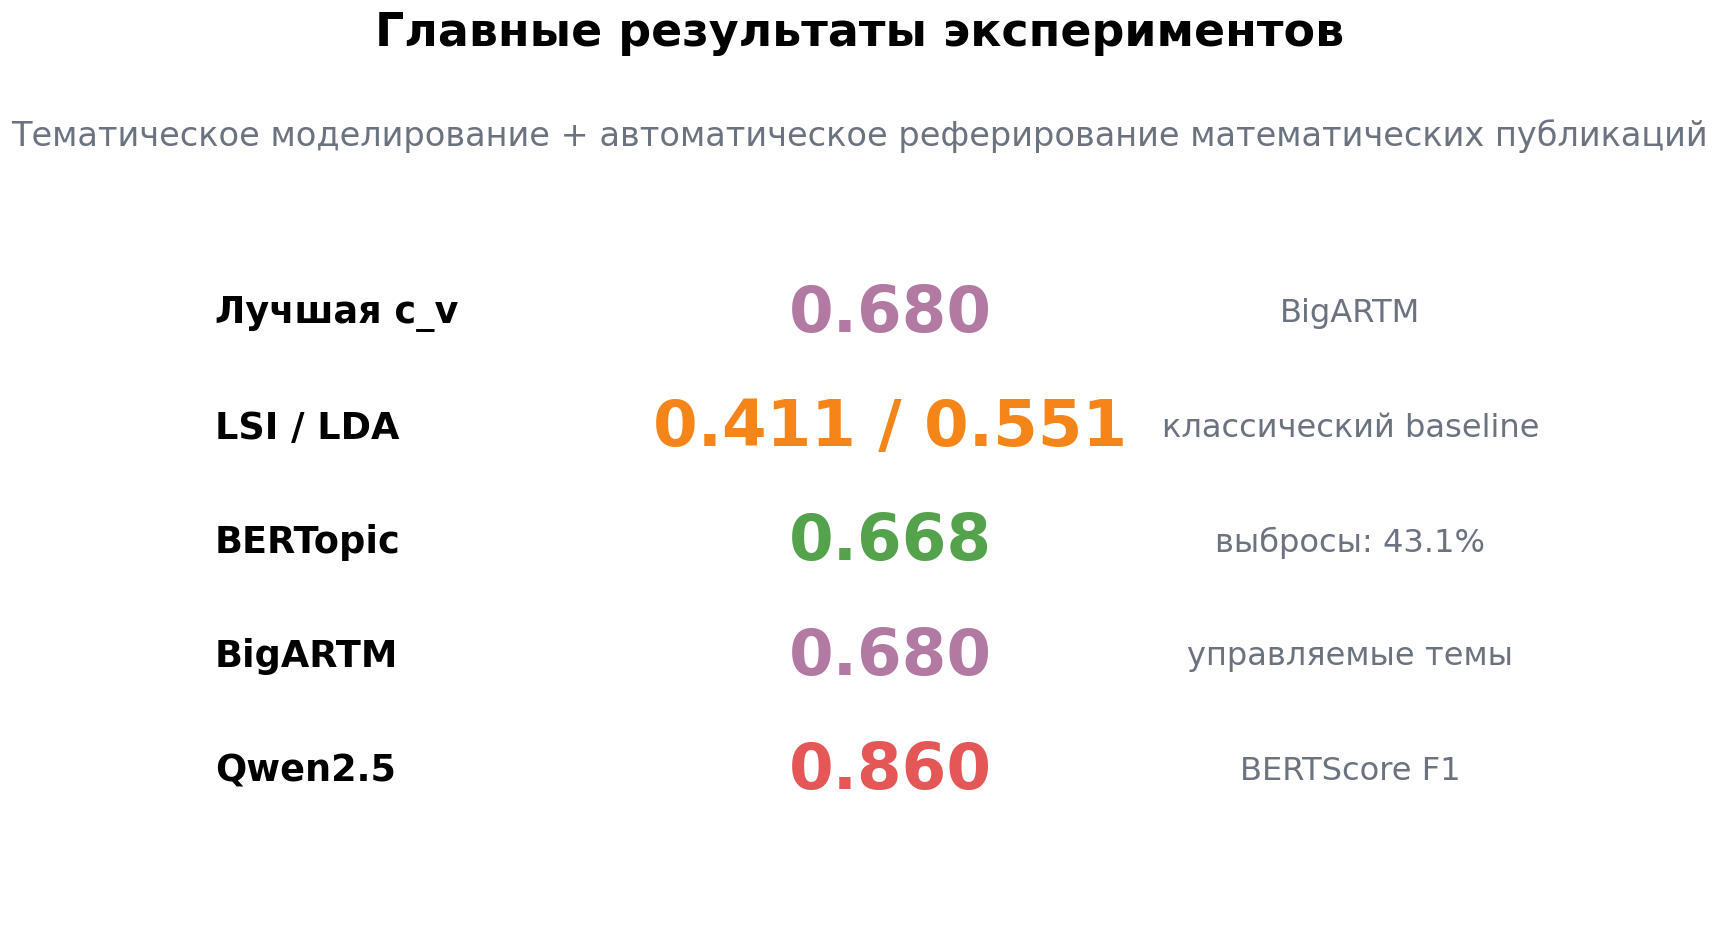

In [ ]:
# Ключевые выводы.
m = metrics_df.set_index(metrics_df["model"].astype(str))

def safe_metric(model, col, default=np.nan):
    try:
        return float(m.loc[model, col])
    except Exception:
        return default

lsi_cv = safe_metric("LSI", "coherence_cv")
lda_cv = safe_metric("LDA", "coherence_cv")
bert_cv = safe_metric("BERTopic", "coherence_cv")
artm_cv = safe_metric("BigARTM", "coherence_cv")

best_model = metrics_df.sort_values("coherence_cv", ascending=False).iloc[0]
best_label = str(best_model["model"])
best_cv = float(best_model["coherence_cv"])

# BERTopic outliers if available.
if bertopic_docs is not None and "topic" in bertopic_docs.columns and len(bertopic_docs) > 0:
    outlier_share = float((bertopic_docs["topic"] == -1).mean())
    outlier_text = f"{outlier_share:.1%}"
else:
    outlier_text = "43.1%"

# Summarization BERTScore.
try:
    bs_value = float(summ_df.loc[summ_df["metric"] == "BERTScore", "value"].iloc[0])
    bs_text = f"{bs_value:.3f}"
except Exception:
    bs_text = "—"

fig, ax = plt.subplots(figsize=(18, 10))
rows = [
    ("Лучшая c_v", f"{best_cv:.3f}", best_label, COLORS.get(best_label, COLORS["gray"])),
    ("LSI / LDA", f"{lsi_cv:.3f} / {lda_cv:.3f}", "классический baseline", COLORS["LDA"]),
    ("BERTopic", f"{bert_cv:.3f}", f"выбросы: {outlier_text}", COLORS["BERTopic"]),
    ("BigARTM", f"{artm_cv:.3f}", "управляемые темы", COLORS["BigARTM"]),
    ("Qwen2.5", bs_text, "BERTScore F1", COLORS["Qwen2.5"]),
]
plot_value_cards(
    ax,
    rows,
    "Главные результаты экспериментов",
    "Тематическое моделирование + автоматическое реферирование математических публикаций",
)

save_figure(
    "14_key_results_dashboard.png",
    "Сводный слайд с ключевыми результатами",
    "Можно использовать как итоговый слайд перед выводами",
)
plt.show()

In [20]:
# Манифест созданных изображений.
manifest_df = pd.DataFrame(FIGURE_MANIFEST).drop_duplicates(subset=["file"]).reset_index(drop=True)
manifest_path = PRESENTATION_FIGURES_DIR / "_figures_manifest.csv"
manifest_df.to_csv(manifest_path, index=False, encoding="utf-8")

display(manifest_df)
print("Манифест сохранён:", manifest_path)

,file,title,note
0,figures\presentation\01_coherence_lda_lsi.png,Классические модели: LDA vs LSI по c_v coherence,Вертикальная столбчатая диаграмма для защиты
1,figures\presentation\02_coherence_bigartm_bert...,Современные модели: BigARTM vs BERTopic по c_v...,Вертикальная столбчатая диаграмма для защиты
2,figures\presentation\03_all_models_coherence.png,Все модели: сравнение c_v coherence,Общий график для вывода о лучшем качестве совр...
3,figures\presentation\04_num_topics_comparison.png,Сравнение числа тем в финальных моделях,"Помогает объяснить, почему BERTopic выделил мн..."
4,figures\presentation\05_lsi_topics_search.png,LSI: выбор числа тем по c_v coherence,Используется файл lsi_optimization_results.csv
5,figures\presentation\06_lda_topics_search.png,LDA: оптимизация по c_v coherence,Используется файл lda_optimization_results.csv
6,figures\presentation\07_bigartm_topics_search.png,BigARTM: выбор числа тем,Используется файл bigartm_topics_search.csv
7,figures\presentation\08_bigartm_regularization...,BigARTM: лучшие регуляризаторы,Используется файл bigartm_regularization_searc...
8,figures\presentation\09_bertopic_largest_topic...,BERTopic: крупнейшие темы,Используется файл documents_with_topics.csv
9,figures\presentation\10_bertopic_outlier_share...,BERTopic: документы в темах и выбросы,Показывает ограничение BERTopic на данном корпусе


Манифест сохранён: c:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\presentation\_figures_manifest.csv
